# Task 2 — Exploratory Data Analysis (EDA)

**Auspify Technologies — Data Science Internship Program**

**Intern:** Wandiya James
**Dataset:** `netflix_cleaned.csv` (output of Task 1)
**Objective:** Explore the Netflix dataset to uncover trends, patterns and insights.

---

### Notebook structure

| Section | Task 2 step | What happens |
|---|---|---|
| 1 | — | Setup and loading the cleaned dataset |
| 2 | Step 1 | Dataset structure and summary statistics |
| 3 | Step 2 | Content distribution by type |
| 4 | Step 3 | Top countries and categories |
| 5 | Step 4 | Trends over time — the key metrics |
| 6 | Step 5 | Summary of findings |

This notebook picks up directly from Task 1. It reads `output/netflix_cleaned.csv` rather than the raw
file, so the derived columns created during cleaning (`year_added`, `primary_genre`,
`audience_category`, `years_to_platform`) are available from the start.

Each chart sits in its own cell with the interpretation written underneath it. A chart without a
reading is decoration — the point of EDA is what the picture tells you.

### Analytical approach

The analysis follows the standard EDA progression, moving from one variable at a time to several
at once:

| Level | Question it answers | Sections |
|---|---|---|
| **Univariate** | What does a single variable look like on its own? | 2, 3, 4 |
| **Bivariate** | How do two variables relate to each other? | 5, 6 |
| **Multivariate** | What happens when three or more interact? | 7 |

Each level can reveal things the one before it hides. A variable that looks unremarkable alone often
turns out to be interesting once it is crossed with another.

---
## 1. Setup and loading the cleaned dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

# A consistent palette so the charts read as one piece of work
NAVY = "#1f3a5f"
BLUE = "#2980b9"
PURPLE = "#8e44ad"
RED = "#c0392b"
GREEN = "#27ae60"
ORANGE = "#e67e22"
GREY = "#95a5a6"

print("Setup complete.")

Setup complete.


The cleaned file stores the list columns (`genres`, `countries`) as comma-separated strings,
because CSV cannot hold a Python list. The loader below restores them, using the snippet produced at
the end of Task 1.

In [2]:
CLEAN_PATH = Path("output/netflix_cleaned.csv")

if not CLEAN_PATH.exists():
    for candidate in [Path("netflix_cleaned.csv"),
                      Path("../task_1/output/netflix_cleaned.csv"),
                      Path("data/netflix_cleaned.csv")]:
        if candidate.exists():
            CLEAN_PATH = candidate
            break
    else:
        raise FileNotFoundError(
            "Could not find netflix_cleaned.csv. Run the Task 1 notebook first, "
            "or set CLEAN_PATH to its location."
        )

df = pd.read_csv(CLEAN_PATH, parse_dates=["date_added"])

# Restore the list columns
df["genres"] = df["genres"].fillna("").str.split(", ")
df["countries"] = df["countries"].fillna("").str.split(", ")

print(f"Loaded : {CLEAN_PATH}")
print(f"Shape  : {df.shape[0]:,} rows x {df.shape[1]} columns")

Loaded : output/netflix_cleaned.csv
Shape  : 8,786 rows x 28 columns


---
## 2. Step 1 — Dataset structure and summary statistics

In [3]:
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration_raw,genres_raw,year_added,month_added,month_name_added,years_to_platform,duration_value,duration_unit,movie_minutes,tv_seasons,audience_category,genres,primary_genre,n_genres,countries,primary_country,runtime_outlier,release_added_inconsistent,director_known,country_known
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,2021,9,September,1,90,min,90.0,NaN,Teens,[Documentaries],Documentaries,1,[United States],United States,False,False,True,True
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",2021,9,September,0,1,Season,NaN,1.0,Adults,"[Crime TV Shows, International TV Shows, TV Ac...",Crime TV Shows,3,[France],France,False,False,True,True
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",2021,9,September,0,1,Season,NaN,1.0,Adults,"[TV Dramas, TV Horror, TV Mysteries]",TV Dramas,3,[United States],United States,False,False,True,True
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",2021,9,September,0,91,min,91.0,NaN,Teens,"[Children & Family Movies, Comedies]",Children & Family Movies,2,[Brazil],Brazil,False,False,True,True
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",2021,9,September,28,125,min,125.0,NaN,Adults,"[Dramas, Independent Movies, International Mov...",Dramas,3,[United States],United States,False,False,True,True


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8786 entries, 0 to 8785
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   show_id                     8786 non-null   str           
 1   type                        8786 non-null   str           
 2   title                       8786 non-null   str           
 3   director                    8786 non-null   str           
 4   country                     8786 non-null   str           
 5   date_added                  8786 non-null   datetime64[us]
 6   release_year                8786 non-null   int64         
 7   rating                      8786 non-null   str           
 8   duration_raw                8786 non-null   str           
 9   genres_raw                  8786 non-null   str           
 10  year_added                  8786 non-null   int64         
 11  month_added                 8786 non-null   int64         
 12  mon

### Numeric summary

In [5]:
numeric_summary = df[["release_year", "year_added", "duration_value",
                      "movie_minutes", "tv_seasons", "years_to_platform",
                      "n_genres"]].describe().T.round(1)
numeric_summary

,count,mean,std,min,25%,50%,75%,max
release_year,8786.0,2014.2,8.8,1925.0,2013.0,2017.0,2019.0,2021.0
year_added,8786.0,2018.9,1.6,2008.0,2018.0,2019.0,2020.0,2021.0
duration_value,8786.0,69.9,50.8,1.0,2.0,88.0,106.0,312.0
movie_minutes,6123.0,99.6,28.3,3.0,87.0,98.0,114.0,312.0
tv_seasons,2663.0,1.8,1.6,1.0,1.0,1.0,2.0,17.0
years_to_platform,8786.0,4.7,8.8,-3.0,0.0,1.0,5.0,93.0
n_genres,8786.0,2.2,0.8,1.0,2.0,2.0,3.0,3.0


Three things to pull out of that table before moving on.

`release_year` runs from 1925 to 2021, but the 25th percentile sits at 2013 — so three quarters of the
catalogue was released in the last decade of the window. This is not a film archive; it is a
predominantly recent library.

`years_to_platform` has a median of 1. The typical title reaches Netflix about a year after release,
which is much faster than the traditional licensing cycle and hints at how much of this is
Netflix-commissioned.

`movie_minutes` and `tv_seasons` have very different counts because each only applies to one content
type — the split created in Task 1 working as intended.

### Categorical summary

In [6]:
cat_summary = pd.DataFrame({
    "unique_values": df[["type", "rating", "audience_category", "primary_country",
                         "primary_genre", "director"]].nunique(),
    "most_common": [df[col].mode()[0] for col in
                    ["type", "rating", "audience_category", "primary_country",
                     "primary_genre", "director"]],
})
cat_summary

,unique_values,most_common
type,2,Movie
rating,12,TV-MA
audience_category,5,Adults
primary_country,86,United States
primary_genre,36,Dramas
director,4528,Unknown


### Coverage — what is actually populated

Task 1 preserved which fields were genuinely missing before they were filled. That information is
worth surfacing here, because it defines the limits of what this EDA can claim.

In [7]:
coverage = pd.DataFrame({
    "known": [df["director_known"].sum(), df["country_known"].sum()],
    "unknown": [(~df["director_known"]).sum(), (~df["country_known"]).sum()],
}, index=["director", "country"])
coverage["% known"] = (coverage["known"] / len(df) * 100).round(1)
coverage

,known,unknown,% known
director,6199,2587,70.6
country,8499,287,96.7


Director is unknown for close to 30% of the catalogue, so any director-level analysis below
covers roughly 70% of titles and must be read as such. Country is known for nearly 97%, which is solid
enough to analyse without caveats.

---
## 3. Step 2 — Content distribution by type *(univariate)*

In [8]:
type_counts = df["type"].value_counts()
type_pct = (type_counts / len(df) * 100).round(1)

distribution = pd.DataFrame({"titles": type_counts, "share_%": type_pct})
distribution

,titles,share_%
type,,
Movie,6123,69.7
TV Show,2663,30.3


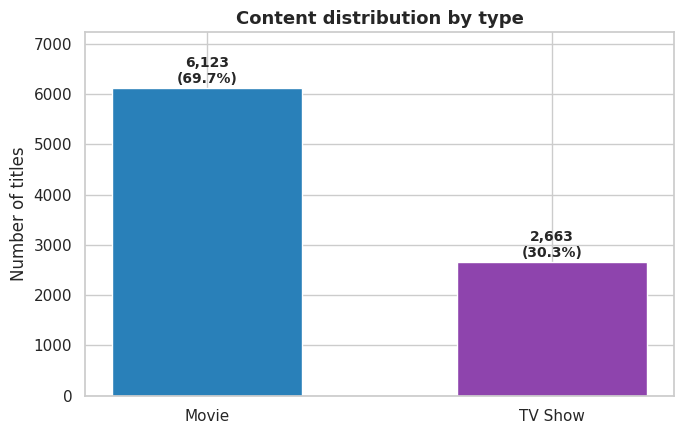

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))

bars = ax.bar(type_counts.index.astype(str), type_counts.values,
              color=[BLUE, PURPLE], width=0.55)

for bar, val, pct in zip(bars, type_counts.values, type_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 100,
            f"{val:,}\n({pct}%)", ha="center", fontweight="bold", fontsize=10)

ax.set_title("Content distribution by type")
ax.set_ylabel("Number of titles")
ax.set_ylim(0, type_counts.max() * 1.18)

plt.tight_layout()
plt.show()

**Movies outnumber TV shows roughly seven to three.** That ratio is the single most basic fact
about the catalogue, and it shapes how everything else should be read — when a genre or a country
looks large, part of the reason may simply be that it is movie-heavy.

Whether that ratio has been stable over time is a more interesting question, and Section 5 answers
it.

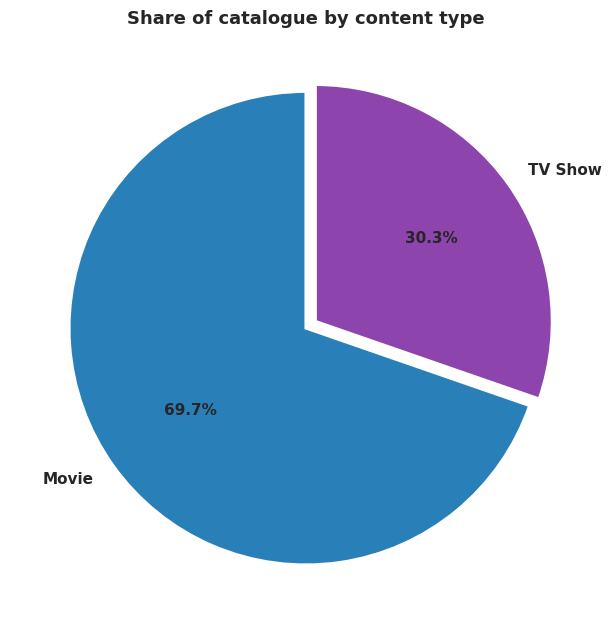

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 6.5))

ax.pie(type_counts.values,
       labels=type_counts.index.astype(str),
       autopct="%1.1f%%",
       colors=[BLUE, PURPLE],
       explode=[0, 0.05],
       startangle=90,
       wedgeprops={"edgecolor": "white", "linewidth": 2},
       textprops={"fontsize": 11, "fontweight": "bold"})

ax.set_title("Share of catalogue by content type")

plt.tight_layout()
plt.show()

The same two numbers as the bar chart, shown as proportions. A pie works here only because there
are exactly two categories — with more than four or five slices the human eye cannot compare angles
reliably and a bar chart is the better choice. It is included because proportion is the natural way to
state this particular split.

### Length profile of each type

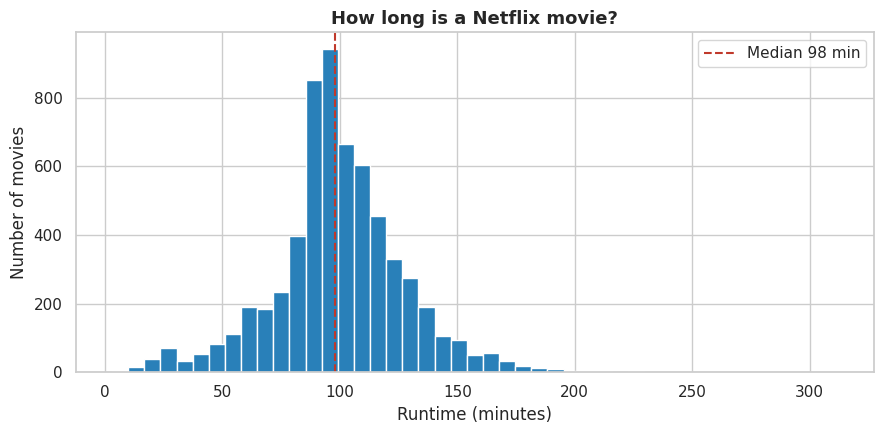

In [11]:
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.hist(df["movie_minutes"].dropna(), bins=45, color=BLUE, edgecolor="white")
ax.axvline(df["movie_minutes"].median(), color=RED, linestyle="--",
           label=f"Median {df['movie_minutes'].median():.0f} min")

ax.set_title("How long is a Netflix movie?")
ax.set_xlabel("Runtime (minutes)")
ax.set_ylabel("Number of movies")
ax.legend()

plt.tight_layout()
plt.show()

A tight peak just under 100 minutes, with thin tails on both sides. The distribution is close to
normal through the middle but not at the edges — those tails are the short films and epics examined in
Task 1, kept deliberately.

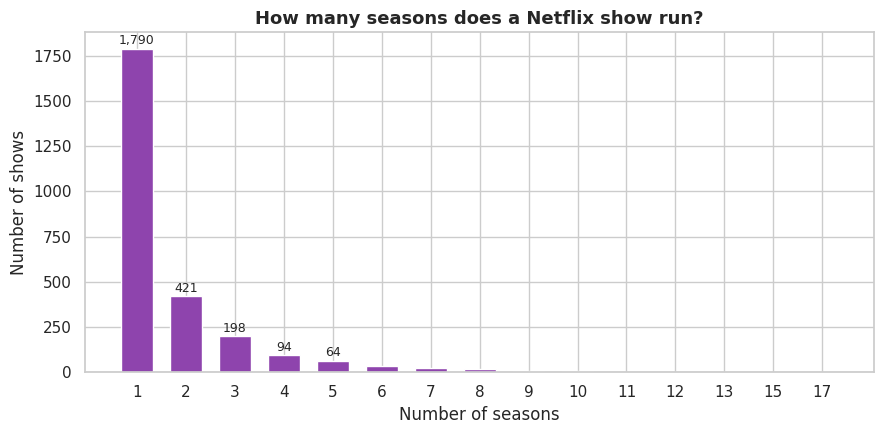

In [12]:
fig, ax = plt.subplots(figsize=(9, 4.5))

season_counts = df["tv_seasons"].value_counts().sort_index()

bars = ax.bar(season_counts.index.astype(int).astype(str), season_counts.values,
              color=PURPLE, width=0.65)

for bar, val in zip(bars, season_counts.values):
    if val > 40:
        ax.text(bar.get_x() + bar.get_width() / 2, val + 25,
                f"{val:,}", ha="center", fontsize=9)

ax.set_title("How many seasons does a Netflix show run?")
ax.set_xlabel("Number of seasons")
ax.set_ylabel("Number of shows")

plt.tight_layout()
plt.show()

In [13]:
one_season = (df["tv_seasons"] == 1).sum()
total_shows = df["tv_seasons"].notna().sum()

print(f"Shows with exactly one season : {one_season:,} of {total_shows:,} "
      f"({one_season / total_shows * 100:.1f}%)")
print(f"Shows running 5+ seasons      : {(df['tv_seasons'] >= 5).sum():,} "
      f"({(df['tv_seasons'] >= 5).sum() / total_shows * 100:.1f}%)")

Shows with exactly one season : 1,790 of 2,663 (67.2%)
Shows running 5+ seasons      : 160 (6.0%)


**Two thirds of Netflix shows run for exactly one season, and only about 7% reach five.**

This is the most striking distribution in the dataset. Some of it is limited series and documentary
formats designed to end after one run — but it also reflects Netflix's well-documented pattern of
cancelling shows early. Either way, a viewer picking a random Netflix series is far more likely to be
starting something self-contained than a long-running saga.

---
## 4. Step 3 — Top countries and categories *(univariate)*

### Producing countries

In [14]:
country_counts = (df.loc[df["country_known"], "primary_country"]
                  .value_counts()
                  .head(15))

country_table = pd.DataFrame({
    "titles": country_counts,
    "share_%": (country_counts / df["country_known"].sum() * 100).round(1),
})
country_table

,titles,share_%
primary_country,,
United States,3240,38.1
India,1056,12.4
United Kingdom,638,7.5
Pakistan,420,4.9
Canada,271,3.2
Japan,259,3.0
South Korea,214,2.5
France,213,2.5
Spain,182,2.1


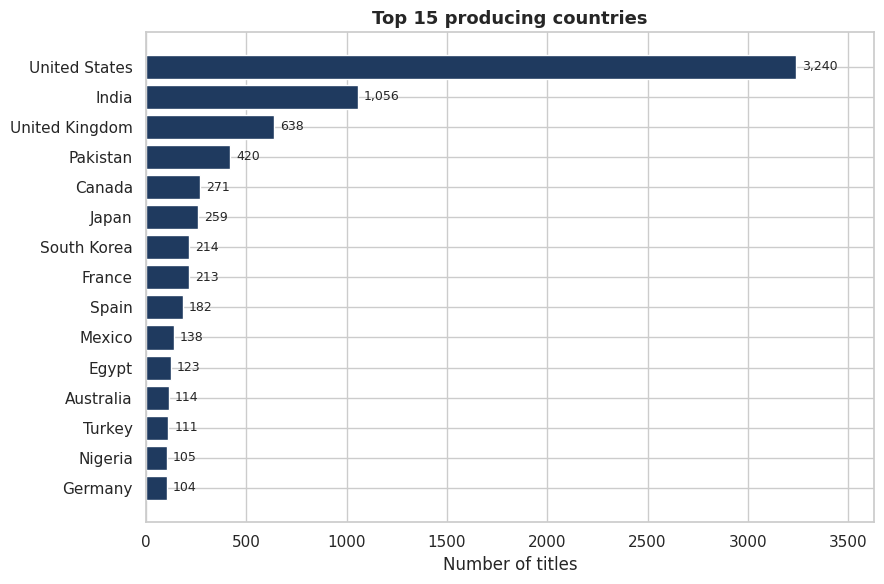

In [15]:
fig, ax = plt.subplots(figsize=(9, 6))

top15 = country_counts.sort_values()
bars = ax.barh(top15.index, top15.values, color=NAVY)

for bar, val in zip(bars, top15.values):
    ax.text(val + 30, bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", fontsize=9)

ax.set_title("Top 15 producing countries")
ax.set_xlabel("Number of titles")
ax.set_xlim(0, top15.max() * 1.12)

plt.tight_layout()
plt.show()

**The United States accounts for around 38% of the catalogue** — dominant, but far from the whole
picture. India is a clear second, and the presence of Pakistan, Japan, South Korea, Spain and France in
the top ten shows a genuinely international library rather than an American one with imports attached.

The next chart shows something more surprising about those countries.

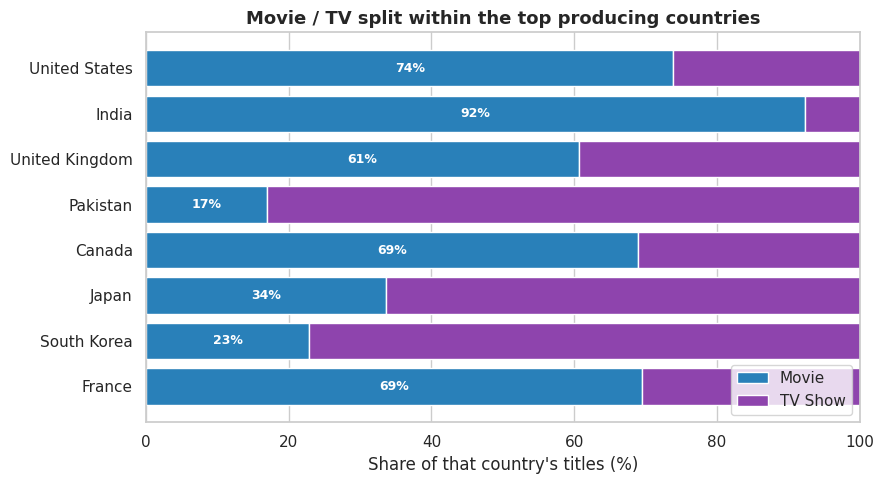

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))

top_countries = country_counts.head(8).index
mix = pd.crosstab(df.loc[df["primary_country"].isin(top_countries), "primary_country"],
                  df["type"], normalize="index").mul(100)
mix = mix.loc[country_counts.head(8).index[::-1]]

ax.barh(mix.index, mix["Movie"], color=BLUE, label="Movie")
ax.barh(mix.index, mix["TV Show"], left=mix["Movie"], color=PURPLE, label="TV Show")

for i, (idx, row) in enumerate(mix.iterrows()):
    ax.text(row["Movie"] / 2, i, f"{row['Movie']:.0f}%", ha="center",
            va="center", color="white", fontweight="bold", fontsize=9)

ax.set_title("Movie / TV split within the top producing countries")
ax.set_xlabel("Share of that country's titles (%)")
ax.set_xlim(0, 100)
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

**The country mixes are wildly different, and that is the finding.**

India is over 90% movies — a straight reflection of its film industry's scale. Pakistan is the mirror
image at over 80% TV shows, almost entirely serialised drama. The United States sits near the overall
average at roughly three quarters movies.

The practical lesson: *"what does Netflix's catalogue look like"* has no single answer. It depends
entirely on which country you ask about. Any later model using country as a feature is picking up this
structure, whether or not it is made explicit.

### Genres

A title can carry several genres, so the column is exploded before counting — otherwise a title tagged
*Dramas, International Movies* would be counted under a single combined label rather than under each
genre.

In [17]:
genre_counts = df.explode("genres")["genres"].value_counts().head(15)

genre_table = pd.DataFrame({
    "titles": genre_counts,
    "share_of_catalogue_%": (genre_counts / len(df) * 100).round(1),
})
genre_table

,titles,share_of_catalogue_%
genres,,
International Movies,2751,31.3
Dramas,2423,27.6
Comedies,1673,19.0
International TV Shows,1348,15.3
Documentaries,869,9.9
Action & Adventure,859,9.8
TV Dramas,761,8.7
Independent Movies,755,8.6
Children & Family Movies,641,7.3


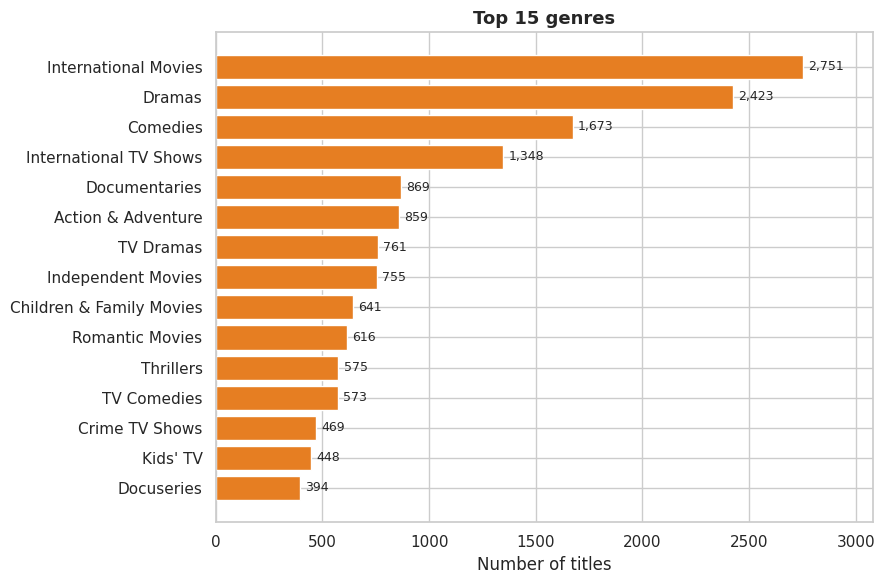

In [18]:
fig, ax = plt.subplots(figsize=(9, 6))

top_genres = genre_counts.sort_values()
bars = ax.barh(top_genres.index, top_genres.values, color=ORANGE)

for bar, val in zip(bars, top_genres.values):
    ax.text(val + 25, bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", fontsize=9)

ax.set_title("Top 15 genres")
ax.set_xlabel("Number of titles")
ax.set_xlim(0, top_genres.max() * 1.12)

plt.tight_layout()
plt.show()

**"International Movies" is the largest single genre tag in the catalogue** — larger than Dramas,
larger than Comedies. That is a revealing label, because it is defined relative to a US viewer rather
than describing the content itself.

It tells you two things at once. Netflix's catalogue is heavily non-American, and Netflix's own
metadata is written from an American point of view. Both matter for Task 3: a recommendation system
built on these tags will treat "international" as a content feature, when it is really a statement
about where the viewer is assumed to be.

### Maturity ratings

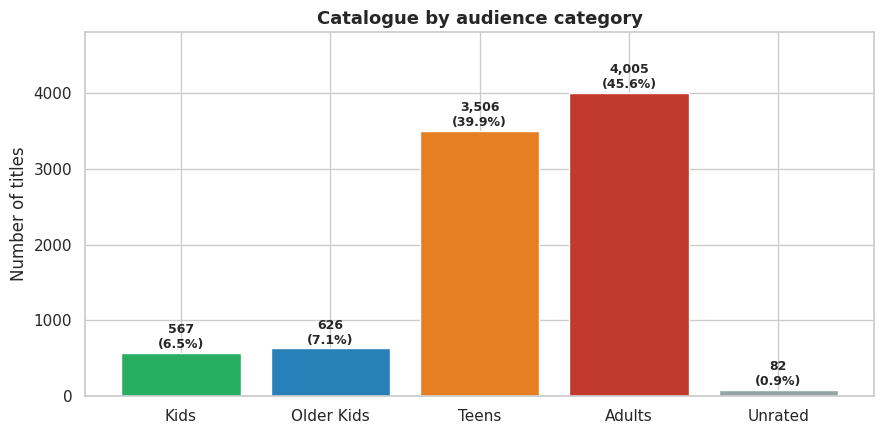

In [19]:
fig, ax = plt.subplots(figsize=(9, 4.5))

audience_counts = df["audience_category"].value_counts()
order = ["Kids", "Older Kids", "Teens", "Adults", "Unrated"]
audience_counts = audience_counts.reindex([o for o in order if o in audience_counts.index])

bars = ax.bar(audience_counts.index, audience_counts.values,
              color=[GREEN, BLUE, ORANGE, RED, GREY][:len(audience_counts)])

for bar, val in zip(bars, audience_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 60,
            f"{val:,}\n({val / len(df) * 100:.1f}%)",
            ha="center", fontsize=9, fontweight="bold")

ax.set_title("Catalogue by audience category")
ax.set_ylabel("Number of titles")
ax.set_ylim(0, audience_counts.max() * 1.20)

plt.tight_layout()
plt.show()

**Adult and teen content together make up over 80% of the catalogue.** Children's content is a
small minority. Netflix positions itself as a family service, but the library itself is built for
grown-ups.

---
## 5. Step 4 — Trends over time *(bivariate: every variable against time)*

This is where EDA moves from describing the catalogue to explaining how it got that way.

### 5.1 Growth of the catalogue

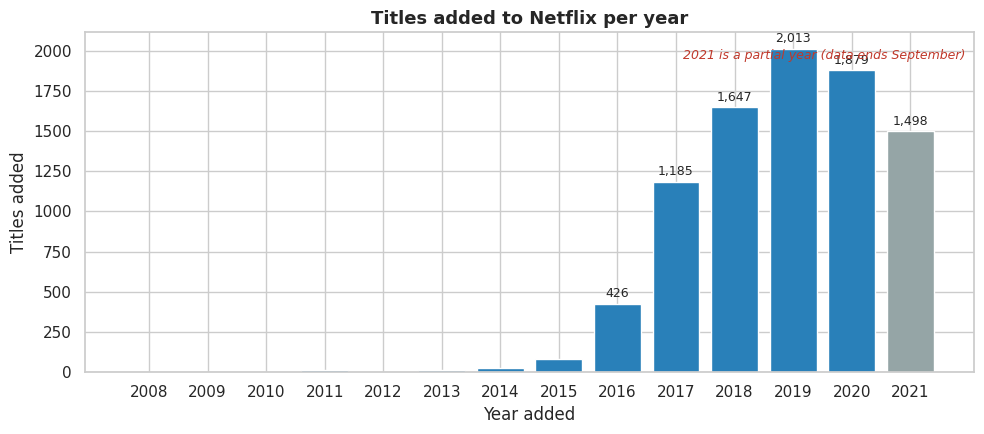

In [20]:
fig, ax = plt.subplots(figsize=(10, 4.5))

per_year = df["year_added"].value_counts().sort_index()
per_year = per_year[per_year.index >= 2008]

colors = [GREY if yr == 2021 else BLUE for yr in per_year.index]
bars = ax.bar(per_year.index.astype(int).astype(str), per_year.values, color=colors)

for bar, val in zip(bars, per_year.values):
    if val > 100:
        ax.text(bar.get_x() + bar.get_width() / 2, val + 40,
                f"{val:,}", ha="center", fontsize=9)

ax.set_title("Titles added to Netflix per year")
ax.set_ylabel("Titles added")
ax.set_xlabel("Year added")
ax.text(0.99, 0.95, "2021 is a partial year (data ends September)",
        transform=ax.transAxes, ha="right", va="top",
        fontsize=9, style="italic", color=RED)

plt.tight_layout()
plt.show()

**Almost nothing until 2015, a steep climb to a peak in 2019, then decline.**

The inflection around 2015-2016 is Netflix shifting from licensing other studios' back catalogues to
commissioning its own content at scale. The 2020 dip is COVID halting production worldwide.

**The 2021 bar is greyed out deliberately.** The data ends in September 2021, so that bar covers nine
months against twelve for every other year. Reading it as a continued decline would be a mistake — and
it is exactly the trap waiting in Task 4, where an unadjusted forecast will treat a truncated year as a
real drop.

### 5.2 Has the movie / TV balance shifted?

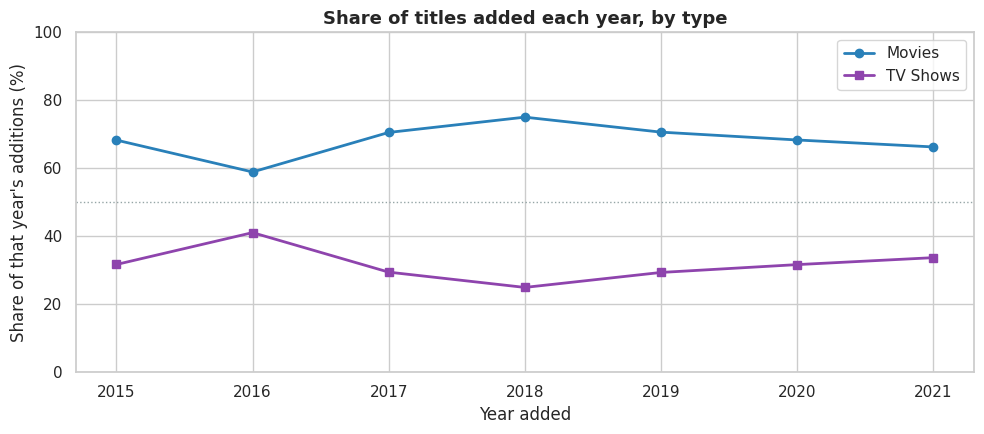

In [21]:
fig, ax = plt.subplots(figsize=(10, 4.5))

mix_by_year = pd.crosstab(df["year_added"], df["type"])
mix_by_year = mix_by_year[mix_by_year.sum(axis=1) >= 50]
share = mix_by_year.div(mix_by_year.sum(axis=1), axis=0).mul(100)

ax.plot(share.index.astype(int), share["Movie"], marker="o",
        color=BLUE, linewidth=2, label="Movies")
ax.plot(share.index.astype(int), share["TV Show"], marker="s",
        color=PURPLE, linewidth=2, label="TV Shows")

ax.axhline(50, color=GREY, linestyle=":", linewidth=1)
ax.set_title("Share of titles added each year, by type")
ax.set_ylabel("Share of that year's additions (%)")
ax.set_xlabel("Year added")
ax.set_ylim(0, 100)
ax.legend()

plt.tight_layout()
plt.show()

In [22]:
print("TV share of yearly additions")
print((mix_by_year["TV Show"] / mix_by_year.sum(axis=1) * 100).round(1).to_string())

TV share of yearly additions
year_added
2015    31.7
2016    41.1
2017    29.5
2018    25.0
2019    29.4
2020    31.7
2021    33.7


**The gap is closing.** TV shows fell to a quarter of additions in 2018, then climbed steadily to
around a third by 2021. Movies still lead comfortably, but the direction of travel over the last three
years is consistent.

This matters for how you read the 70/30 headline split from Section 3: that ratio is a *cumulative*
figure reflecting years of movie-heavy acquisition. The recent flow looks different from the stock.

### 5.3 How quickly does content reach the platform?

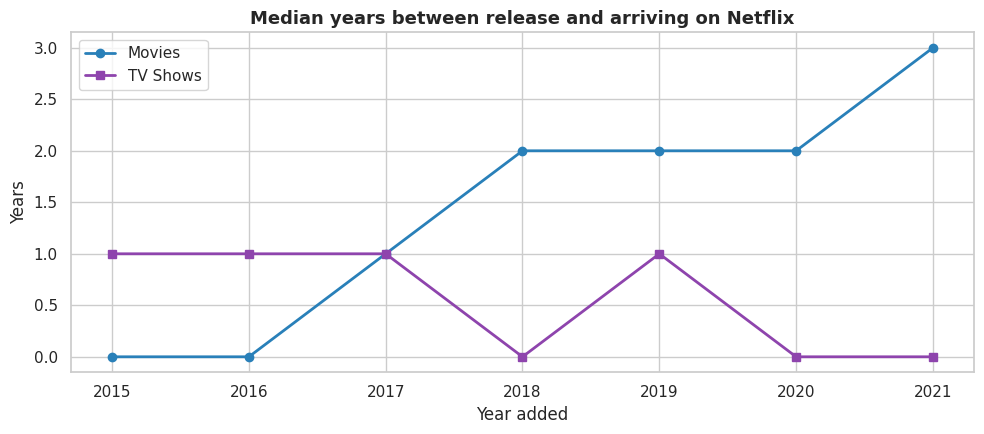

In [23]:
fig, ax = plt.subplots(figsize=(10, 4.5))

lag = (df[df["year_added"] >= 2015]
       .groupby(["year_added", "type"])["years_to_platform"]
       .median()
       .unstack())

ax.plot(lag.index.astype(int), lag["Movie"], marker="o",
        color=BLUE, linewidth=2, label="Movies")
ax.plot(lag.index.astype(int), lag["TV Show"], marker="s",
        color=PURPLE, linewidth=2, label="TV Shows")

ax.set_title("Median years between release and arriving on Netflix")
ax.set_ylabel("Years")
ax.set_xlabel("Year added")
ax.legend()

plt.tight_layout()
plt.show()

**TV shows arrive the same year they are released; movies lag by about a year.**

A median of zero for TV is effectively simultaneous — which is what you would expect when Netflix is
the producer rather than a licensee. The persistent one-year gap for movies reflects the theatrical and
home-release windows that films still pass through first.

This single chart captures Netflix's transformation better than almost anything else in the dataset:
the company is no longer primarily buying old content, it is releasing new content.

### 5.4 Are movies getting shorter?

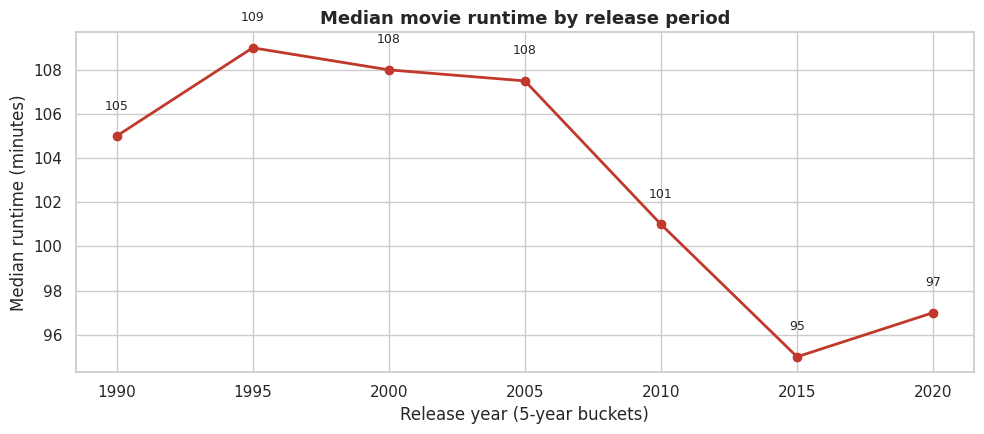

In [24]:
fig, ax = plt.subplots(figsize=(10, 4.5))

runtime_trend = (df[df["release_year"] >= 1990]
                 .groupby(df["release_year"] // 5 * 5)["movie_minutes"]
                 .median()
                 .dropna())

ax.plot(runtime_trend.index.astype(int), runtime_trend.values,
        marker="o", color=RED, linewidth=2)

for x, y in zip(runtime_trend.index.astype(int), runtime_trend.values):
    ax.text(x, y + 1.2, f"{y:.0f}", ha="center", fontsize=9)

ax.set_title("Median movie runtime by release period")
ax.set_ylabel("Median runtime (minutes)")
ax.set_xlabel("Release year (5-year buckets)")

plt.tight_layout()
plt.show()

**Yes — and by a meaningful amount.** The median film released in the mid-1990s runs about 109
minutes; by the mid-2010s that has fallen to around 95. Roughly a quarter of an hour shorter in twenty
years.

A caveat worth stating: this is not evidence that *cinema* is getting shorter. It is evidence that the
films Netflix carries are getting shorter, which mixes a genuine industry trend with Netflix's own
acquisition preferences. Distinguishing the two would need data this dataset does not contain.

### 5.5 Has the audience mix changed?

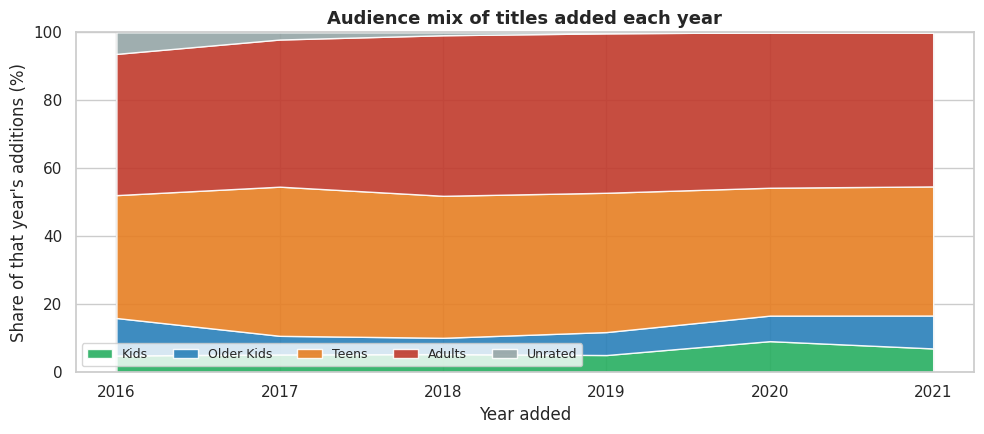

In [25]:
fig, ax = plt.subplots(figsize=(10, 4.5))

aud = pd.crosstab(df["year_added"], df["audience_category"], normalize="index").mul(100)
aud = aud[aud.index >= 2016]
order = [o for o in ["Kids", "Older Kids", "Teens", "Adults", "Unrated"] if o in aud.columns]
aud = aud[order]

ax.stackplot(aud.index.astype(int), [aud[col] for col in order],
             labels=order, colors=[GREEN, BLUE, ORANGE, RED, GREY][:len(order)],
             alpha=0.9)

ax.set_title("Audience mix of titles added each year")
ax.set_ylabel("Share of that year's additions (%)")
ax.set_xlabel("Year added")
ax.set_ylim(0, 100)
ax.legend(loc="lower left", ncol=5, fontsize=9)

plt.tight_layout()
plt.show()

**The mix is remarkably stable** — adults around 45%, teens around 40%, year after year. Netflix
knows who it is buying for and has not changed its mind.

The one visible movement is the *Unrated* band shrinking to nothing after 2019. That is not a content
trend at all; it is Netflix's metadata getting more complete. Worth separating from the real signal —
a change in how data is *recorded* can easily be mistaken for a change in what is happening.

### 5.6 Is there a seasonal pattern to releases?

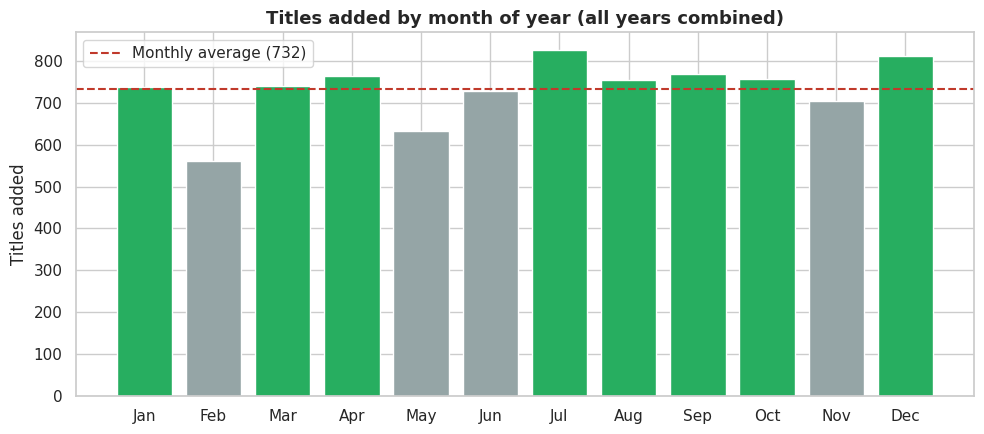

In [26]:
fig, ax = plt.subplots(figsize=(10, 4.5))

monthly = df["month_added"].value_counts().sort_index()
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

avg = monthly.mean()
colors = [GREEN if v > avg else GREY for v in monthly.values]
ax.bar(month_labels, monthly.values, color=colors)
ax.axhline(avg, color=RED, linestyle="--", label=f"Monthly average ({avg:.0f})")

ax.set_title("Titles added by month of year (all years combined)")
ax.set_ylabel("Titles added")
ax.legend()

plt.tight_layout()
plt.show()

**Weaker than you might expect.** July and December are the busiest months and February the
quietest, but the spread between them is modest — the busiest month is only about 1.5 times the
quietest, and part of February's deficit is simply that it has fewer days.

The honest reading is that there is no strong seasonality here. That is a useful negative result:
worth checking, worth reporting, and worth not over-interpreting.

### 5.7 When does the catalogue come from?

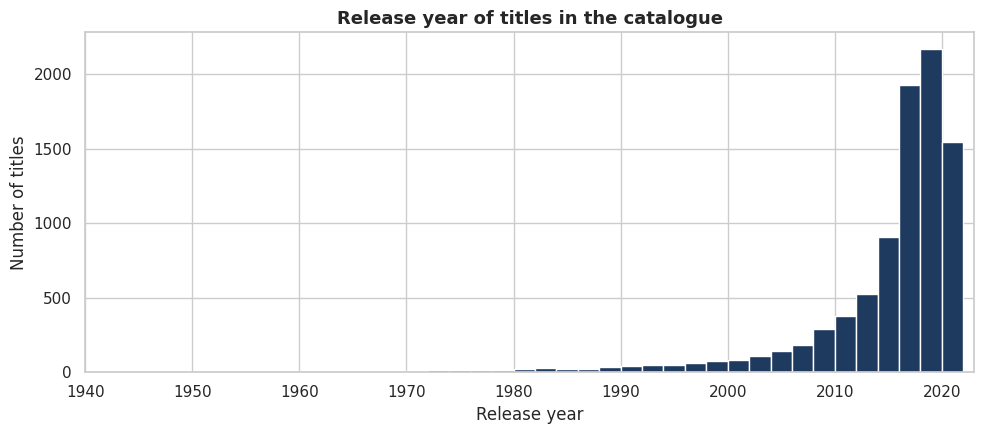

In [27]:
fig, ax = plt.subplots(figsize=(10, 4.5))

ax.hist(df["release_year"], bins=range(1940, 2023, 2), color=NAVY, edgecolor="white")

ax.set_title("Release year of titles in the catalogue")
ax.set_xlabel("Release year")
ax.set_ylabel("Number of titles")
ax.set_xlim(1940, 2023)

plt.tight_layout()
plt.show()

In [28]:
recent = (df["release_year"] >= 2010).sum()
print(f"Released 2010 or later : {recent:,} of {len(df):,} ({recent / len(df) * 100:.1f}%)")
print(f"Released before 1990   : {(df['release_year'] < 1990).sum():,} "
      f"({(df['release_year'] < 1990).sum() / len(df) * 100:.1f}%)")

Released 2010 or later : 7,454 of 8,786 (84.8%)
Released before 1990   : 251 (2.9%)


**Around 80% of the catalogue was released in 2010 or later; under 3% predates 1990.** The
distribution is extremely skewed toward the present, with a long flat tail into the past.

Netflix is not a film archive. Anyone expecting depth in classic cinema is looking at the wrong
service, and any model trained on this data will know almost nothing about pre-2000 content.

---
## 6. Bivariate analysis — relationships between variables

Sections 3 to 5 looked at variables one at a time, or against time. This section asks a different
question: do the numeric features move together?

In [29]:
numeric_cols = ["release_year", "year_added", "years_to_platform",
                "movie_minutes", "tv_seasons", "n_genres"]

corr = df[numeric_cols].corr().round(2)
corr

,release_year,year_added,years_to_platform,movie_minutes,tv_seasons,n_genres
release_year,1.00,0.11,-0.98,-0.21,-0.08,-0.04
year_added,0.11,1.00,0.07,0.12,0.04,0.05
years_to_platform,-0.98,0.07,1.00,0.23,0.10,0.05
movie_minutes,-0.21,0.12,0.23,1.00,NaN,0.41
tv_seasons,-0.08,0.04,0.10,NaN,1.00,-0.08
n_genres,-0.04,0.05,0.05,0.41,-0.08,1.00


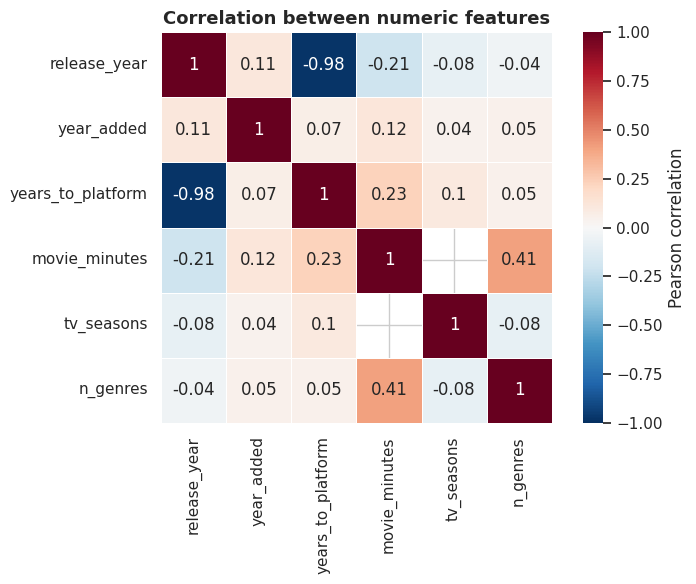

In [30]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, linewidths=0.5, square=True,
            cbar_kws={"label": "Pearson correlation"}, ax=ax)

ax.set_title("Correlation between numeric features")

plt.tight_layout()
plt.show()

**The strongest correlation on this heatmap is meaningless, and recognising that is the point.**

`release_year` and `years_to_platform` correlate at **-0.98**, which looks like a major discovery. It
is not. `years_to_platform` was *calculated* as `year_added - release_year` back in Task 1, so the two
columns are algebraically linked. The correlation is an artifact of construction, not a fact about
Netflix.

The same applies to `duration_value` against `movie_minutes` and `tv_seasons`, which is why
`duration_value` is left out of the matrix above — all three are the same number wearing different
labels.

This is worth taking seriously beyond the chart. Feeding a derived feature and its own parent into a
model is how **data leakage** happens: the model appears to perform brilliantly because it has been
handed the answer in disguise. When you select features for Task 5, `years_to_platform` and
`release_year` should not both go in.

### The one relationship that is real

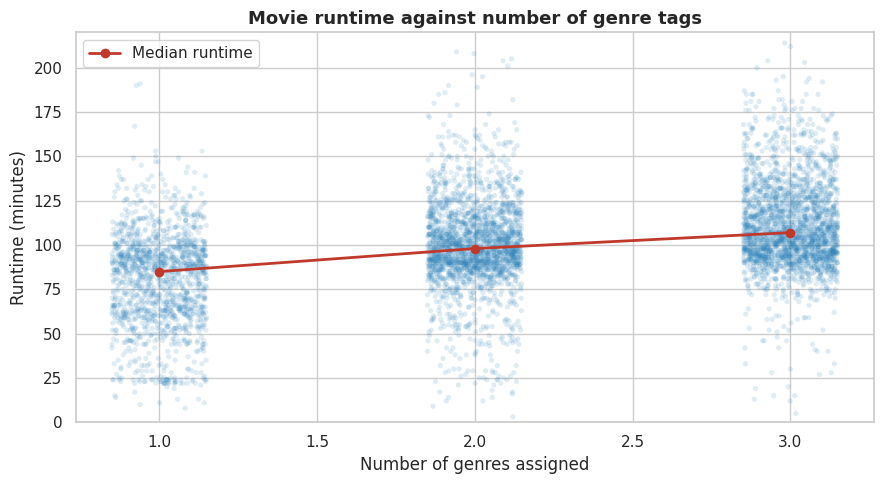

In [31]:
fig, ax = plt.subplots(figsize=(9, 5))

movies = df[df["type"] == "Movie"].dropna(subset=["movie_minutes", "n_genres"])

ax.scatter(movies["n_genres"] + np.random.uniform(-0.15, 0.15, len(movies)),
           movies["movie_minutes"],
           alpha=0.15, s=14, color=BLUE, edgecolors="none")

medians = movies.groupby("n_genres")["movie_minutes"].median()
ax.plot(medians.index, medians.values, color=RED, marker="o",
        linewidth=2, label="Median runtime")

ax.set_title("Movie runtime against number of genre tags")
ax.set_xlabel("Number of genres assigned")
ax.set_ylabel("Runtime (minutes)")
ax.set_ylim(0, 220)
ax.legend()

plt.tight_layout()
plt.show()

In [32]:
print("Median runtime by genre count")
print(movies.groupby("n_genres")["movie_minutes"].agg(["count", "median"]).to_string())
print()
print(f"Correlation: {movies['movie_minutes'].corr(movies['n_genres']):.2f}")

Median runtime by genre count
          count  median
n_genres               
1          1476    85.0
2          2240    98.0
3          2407   107.0

Correlation: 0.41


**Longer films carry more genre tags** — a correlation of about 0.41, which is modest but real and
not obviously predictable in advance.

Two explanations are plausible. A longer film may genuinely contain more material and so span more
categories. Or longer films may simply be bigger productions that receive more thorough metadata. This
dataset cannot separate the two, and saying so is more honest than picking whichever story sounds
better.

Note the jitter added to the x-axis in the code above. Genre count is a whole number, so without it
every point would stack into six vertical lines and the density would be invisible.

### Runtime against release year

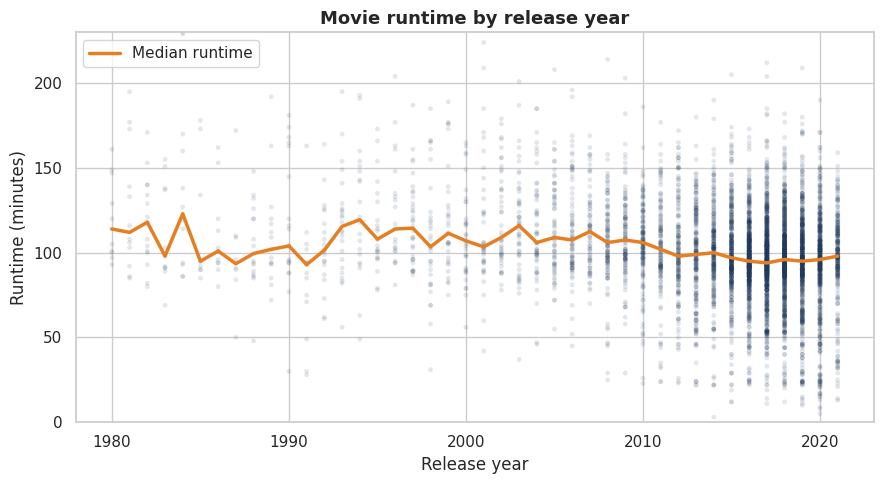

In [33]:
fig, ax = plt.subplots(figsize=(9, 5))

recent = df[(df["type"] == "Movie") & (df["release_year"] >= 1980)]

ax.scatter(recent["release_year"], recent["movie_minutes"],
           alpha=0.12, s=12, color=NAVY, edgecolors="none")

yearly_median = recent.groupby("release_year")["movie_minutes"].median()
ax.plot(yearly_median.index, yearly_median.values,
        color=ORANGE, linewidth=2.5, label="Median runtime")

ax.set_title("Movie runtime by release year")
ax.set_xlabel("Release year")
ax.set_ylabel("Runtime (minutes)")
ax.set_ylim(0, 230)
ax.legend()

plt.tight_layout()
plt.show()

The scatter shows what the summary line in Section 5.4 could not: the *spread* narrows as well as
the median falling. Older films in this catalogue vary widely in length, while recent ones cluster
tightly around 90 to 100 minutes.

Part of that is survivorship — only a thin, unrepresentative selection of older films is on Netflix at
all. But the tightening of recent runtimes is consistent with an industry converging on a standard
length.

---
## 7. Multivariate analysis — three variables at once

Crossing two variables reveals relationships. Crossing three reveals where those relationships
*differ*, which is usually the more useful finding.

In [34]:
pivot = pd.pivot_table(
    df[df["type"] == "Movie"],
    values="movie_minutes",
    index="primary_country",
    columns="audience_category",
    aggfunc="median",
)

top_countries = df["primary_country"].value_counts().head(8).index
pivot = pivot.loc[[c for c in top_countries if c in pivot.index]]
pivot.round(0)

audience_category,Adults,Kids,Older Kids,Teens,Unrated
primary_country,,,,,
United States,94.0,72.0,93.0,95.0,86.0
India,118.0,84.0,76.0,130.0,110.0
United Kingdom,97.0,63.0,95.0,96.0,104.0
Pakistan,65.0,40.0,67.0,117.0,NaN
Unknown,98.0,46.0,66.0,101.0,NaN
Canada,94.0,46.0,91.0,90.0,89.0
Japan,108.0,22.0,98.0,99.0,NaN
South Korea,123.0,62.0,82.0,103.0,133.0


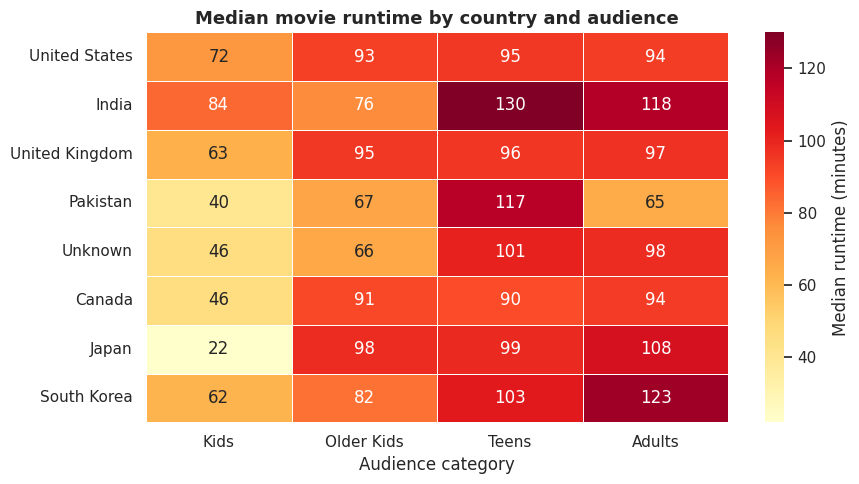

In [35]:
fig, ax = plt.subplots(figsize=(9, 5))

cols = [c for c in ["Kids", "Older Kids", "Teens", "Adults"] if c in pivot.columns]

sns.heatmap(pivot[cols], annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=0.5, cbar_kws={"label": "Median runtime (minutes)"}, ax=ax)

ax.set_title("Median movie runtime by country and audience")
ax.set_xlabel("Audience category")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

**Indian films run dramatically longer than everyone else's, at every audience level.**

The median Indian film for teens runs around 130 minutes against roughly 95 in the US and UK — over
half an hour longer. Adult-rated Indian films sit near 118 minutes while American ones sit at 94. The
pattern holds across the whole row, so this is not one outlier dragging an average.

That is the Bollywood convention of longer, often musical features, visible directly in the data. And
it is a finding that only appears at the multivariate level: runtime alone gives a single global median
of 98 minutes, country alone gives counts, and neither reveals that "typical movie length" means
something different depending on where the film was made.

For Task 5, this means country and runtime **interact** — a classifier using both will do better than
one treating them as independent.

### When content arrives — year against month

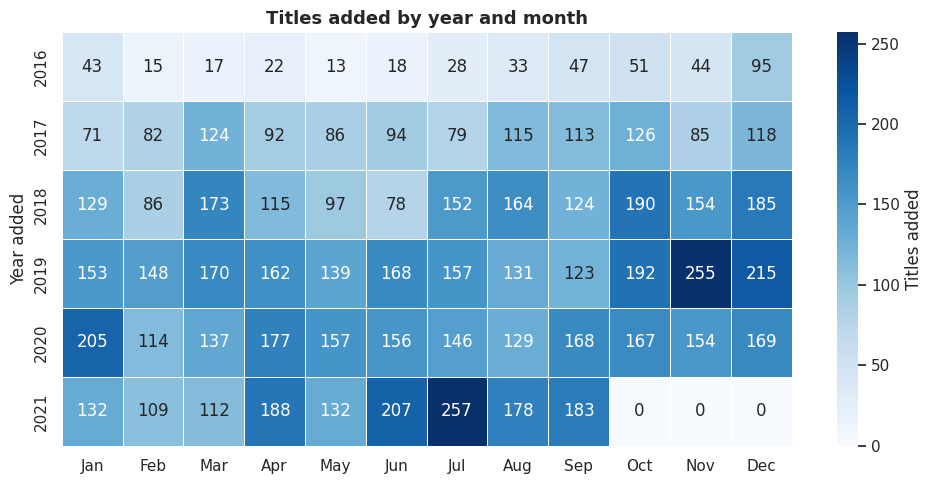


Note the empty cells for Oct-Dec 2021 - the dataset ends in September.


In [36]:
fig, ax = plt.subplots(figsize=(10, 5))

heat = pd.crosstab(df["year_added"], df["month_added"])
heat = heat[heat.index >= 2016]
heat.columns = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"][:len(heat.columns)]

sns.heatmap(heat, annot=True, fmt="d", cmap="Blues",
            linewidths=0.5, cbar_kws={"label": "Titles added"}, ax=ax)

ax.set_title("Titles added by year and month")
ax.set_ylabel("Year added")
ax.set_xlabel("")

plt.tight_layout()
plt.show()

print()
print("Note the empty cells for Oct-Dec 2021 - the dataset ends in September.")

This makes concrete what the greyed-out bar in Section 5.1 only hinted at. The final quarter of
2021 is **empty** — not low, but absent. Any model that treats 2021 as a complete year is comparing
nine months against twelve and will read the gap as a collapse in acquisitions.

The heatmap also shows the monthly pattern is inconsistent from year to year. December is heavy in
2019 and 2020 but not 2017, which supports the conclusion from Section 5.6 that seasonality here is
weak and unreliable.

---
## 8. Step 5 — Summary of findings

### The ten things this analysis established

1. **Movies outnumber TV shows roughly 70 to 30** — but that is a cumulative figure. The share of TV
   in yearly additions has risen from a quarter in 2018 to a third by 2021, so the recent flow looks
   different from the accumulated stock.

2. **Two thirds of TV shows run for exactly one season**, and only about 7% reach five. Whether that
   reflects limited-series formats or early cancellation, a Netflix series is far more likely to be
   self-contained than long-running.

3. **The catalogue is overwhelmingly recent.** Around 80% of titles were released in 2010 or later and
   under 3% before 1990. This is a current-content library, not an archive.

4. **The United States supplies about 38% of titles**, but the top ten includes India, Pakistan, Japan,
   South Korea, Spain and France — a genuinely international catalogue.

5. **Country mixes differ enormously.** India is over 90% movies; Pakistan is over 80% TV shows. There
   is no single answer to what Netflix's catalogue looks like — it depends which country you ask about.

6. **"International Movies" is the single largest genre tag**, which says as much about Netflix's
   US-centric metadata as it does about the content itself.

7. **Growth peaked in 2019.** Additions climbed steeply from 2015, peaked at just over 2,000 titles in
   2019, and fell through 2020 as COVID halted production. The 2021 figure covers nine months only.

8. **TV shows now arrive the same year they are released**, while movies still lag by about a year —
   the clearest signal in the data of Netflix's shift from licensing to producing.

9. **Movies have got shorter**, from a median of about 109 minutes for mid-1990s releases to about 95
   for mid-2010s ones.

10. **Indian films run over half an hour longer than American ones** at every audience level — around
    130 minutes for teen-rated titles against 95 in the US. A finding only visible when country,
    runtime and audience are crossed together.

11. **Longer films carry more genre tags** (correlation 0.41), though whether that reflects richer
    content or simply more thorough metadata on bigger productions cannot be settled here.

12. **The audience mix has barely moved** — adults around 45%, teens around 40%, consistently. The
    apparent decline in *Unrated* content is a metadata improvement, not a content trend.

### What this dataset cannot tell you

Worth stating explicitly, because knowing the limits of the data is part of the analysis:

- **No viewership, ratings or revenue.** Nothing here indicates how popular anything was, so questions
  about Netflix's most successful content are unanswerable.
- **It is a snapshot, not a history.** Only titles present in September 2021 appear. Anything removed
  before then is invisible, which biases the picture toward content Netflix chose to keep.
- **`release_year` means different things by type** — latest season for TV, original release for
  movies, as established in Task 1. Comparisons across types on this field need care.
- **Director is unknown for about 30% of titles**, so director-level findings cover roughly 70% of the
  catalogue.
- **Some columns are derived from others.** `years_to_platform`, `duration_value`, `movie_minutes` and
  `tv_seasons` were all calculated during Task 1. Their correlations with their parent columns describe
  arithmetic, not Netflix, and using both together in a model causes leakage.

### Where this leads

| Task | What this EDA hands over |
|---|---|
| Task 3 — Recommendation system | Genre tags are multi-valued and US-centric; `genres` and `primary_genre` are ready to use |
| Task 4 — Trend prediction | 2021 is a partial year and must be excluded or annualised before forecasting |
| Task 5 — Classification | Country, duration and genre separate Movies from TV Shows strongly. **Do not use `release_year` and `years_to_platform` together** — they correlate at -0.98 by construction and will leak |
| Task 6 — Dashboard | The growth curve, country mix and one-season finding are the strongest stories to lead with |